# Composable multipanel figures in Ephax

This tutorial shows a publishable-at-every-stage plotting workflow:

- vibe-code new processing and plotting together while keeping Nature-safe defaults;
- promote useful outputs into result objects plus standalone `plot_*` functions;
- use `draw_*` functions when you want to render the same content into caller-owned axes;
- stitch repeated child plots under one panel label with shared colorbars when useful;
- use `figure()`, `panel()`, `group()`, and `compose_figure()` for 12-column compound figures;
- use Nature-compatible helpers for style, panel labels, scale bars, and export.

The examples use synthetic data, so the notebook can run without local MEA recordings.

In [29]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# Make the local package importable when running this notebook from Notebooks/.
repo_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ephax import IFRConfig
from ephax.models import CofiringHeatmap, IFRTimeSeriesPanel, PopulationIFR
from ephax.plotting import (
    add_scale_bar,
    apply_paper_style,
    compose_figure,
    draw_cofiring_heatmap,
    draw_ifr_timeseries_panel,
    draw_population_ifr_summary,
    export_figure,
    figure,
    group,
    ifr_timeseries_axes_factory,
    nature_figure_check,
    nature_figure_size,
    panel,
    plot_ifr_timeseries_panel,
    plot_population_ifr_summary,
    population_ifr_summary_axes_factory,
)

apply_paper_style()
rng = np.random.default_rng(7)

## 1. Prepare reusable result objects

The plotting layer expects already-computed result objects. This keeps the rendering code reusable: the same `IFRTimeSeriesPanel`, `PopulationIFR`, or `CofiringHeatmap` can be shown by itself or inserted into a larger figure.

In [30]:
time_s = np.linspace(0.0, 12.0, 240)
electrodes = np.arange(1, 49)

base = 3.0 + 2.0 * np.sin(time_s / 1.7)
rank_gradient = np.linspace(0.6, 1.8, electrodes.size)[:, None]
event = 18.0 * np.exp(-0.5 * ((time_s - 6.0) / 0.65) ** 2)
noise = rng.gamma(shape=1.5, scale=0.5, size=(electrodes.size, time_s.size))
ifr_hz = np.clip(rank_gradient * (base + event) + noise, 0.03, None)

ifr_panel = IFRTimeSeriesPanel(
    recording_index=0,
    start_time=float(time_s[0]),
    end_time=float(time_s[-1]),
    electrodes=electrodes,
    time_points=time_s,
    heatmap=np.log10(ifr_hz),
    histogram_values=np.log10(ifr_hz.ravel()),
    log_scale=True,
)

population = PopulationIFR(
    time_grid=time_s,
    electrodes=electrodes,
    ifr_matrix=ifr_hz,
    mean_ifr=ifr_hz.mean(axis=0),
    mean_ifr_smooth=np.convolve(ifr_hz.mean(axis=0), np.ones(9) / 9.0, mode="same"),
    per_electrode_mean_hz=ifr_hz.mean(axis=1),
)

distance_bins = np.linspace(0.0, 1200.0, 49)
delays_ms = np.linspace(-30.0, 30.0, 61)
distance_centers = 0.5 * (distance_bins[:-1] + distance_bins[1:])
delay_centers = 0.5 * (delays_ms[:-1] + delays_ms[1:])
cofiring_z = np.exp(-distance_centers[None, :] / 450.0) * np.exp(-0.5 * (delay_centers[:, None] / 8.0) ** 2)
cofiring_z += 0.03 * rng.random(cofiring_z.shape)

cofiring = CofiringHeatmap(
    Z=cofiring_z,
    distance_bins=distance_bins,
    delays=delays_ms,
)

ifr_config = IFRConfig(log_scale=True, overlay_gmm=False, ts_bins=40)

## 2. Stage 1: quick exploration that is still publishable

Exploratory figures should be fast, but not disposable. The same Nature-safe style applies; the difference is that you can combine fresh processing and plotting in one notebook cell while testing an idea.

Text(0.5, 0.98, 'Exploratory but publishable standalone result')

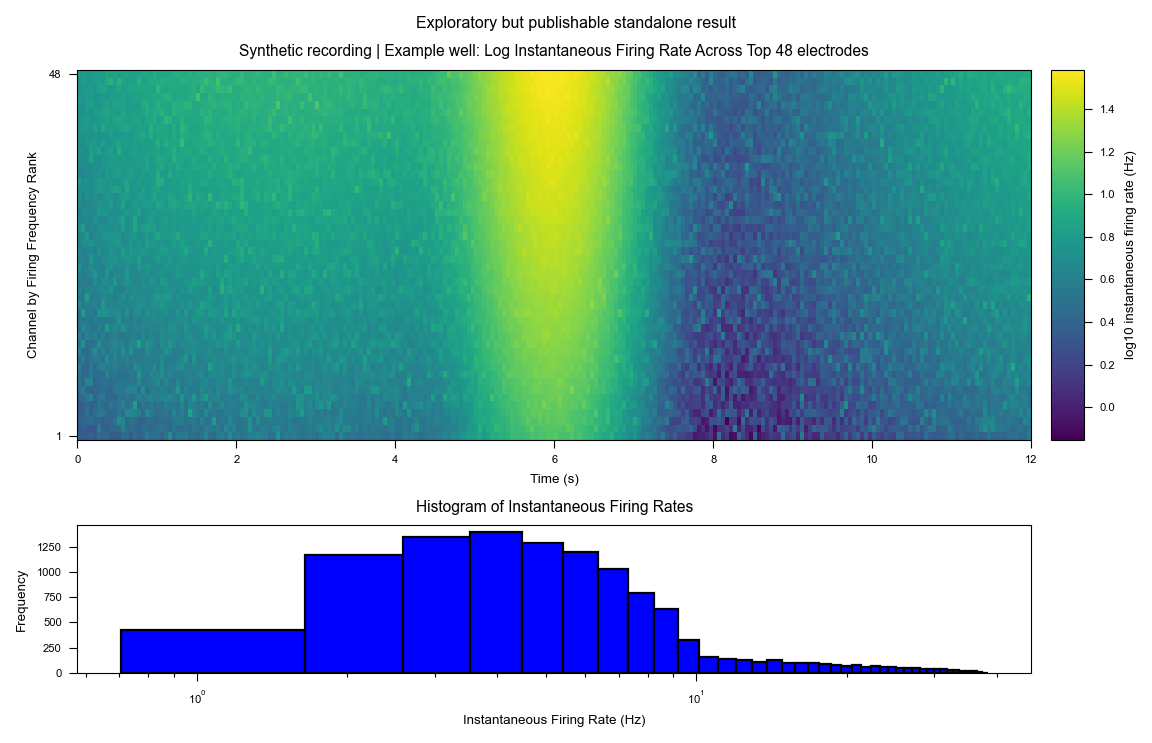

In [31]:
fig, axes = plot_ifr_timeseries_panel(
    ifr_panel,
    ifr_config,
    title="Synthetic recording",
    recording_label="Example well",
)
fig.suptitle("Exploratory but publishable standalone result")

## 3. Stage 2: promoted standalone plot

Once the result is useful, keep computation in a result object and use the standalone `plot_*` wrapper. These wrappers use content-sized defaults rather than forcing a full journal-page width.

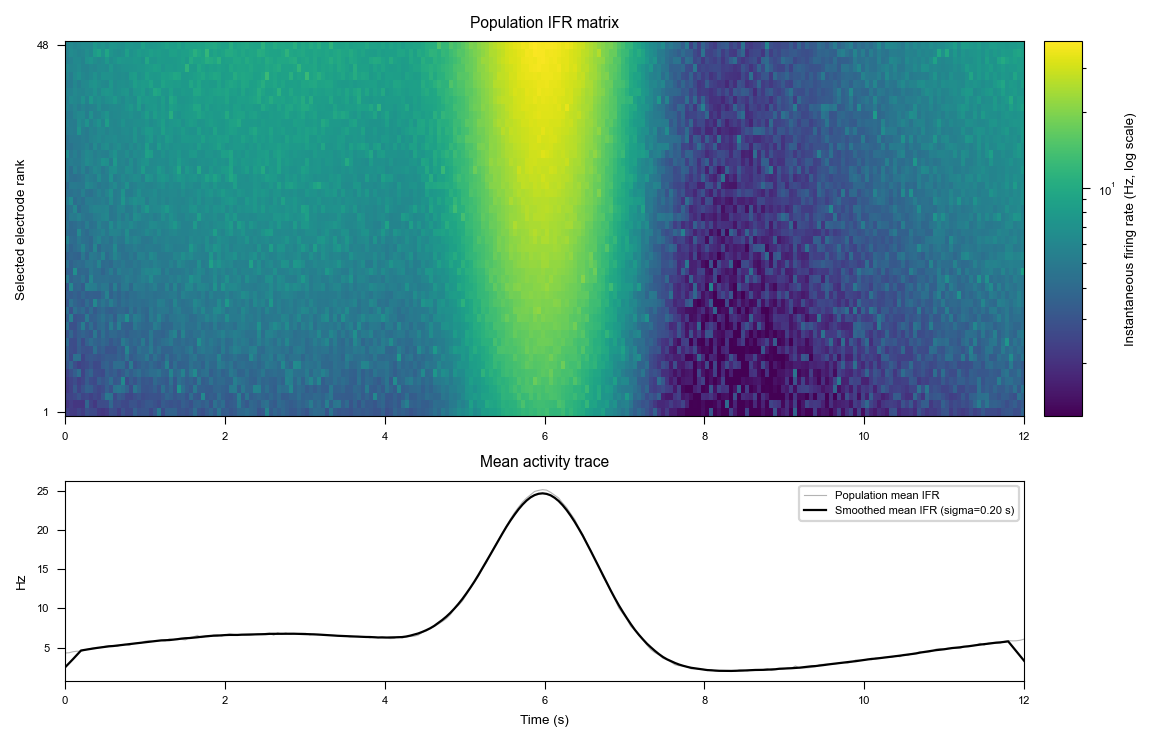

In [32]:
fig, axes = plot_population_ifr_summary(
    population,
    heatmap_title="Population IFR matrix",
    mean_title="Mean activity trace",
    smooth_sigma_sec=0.20,
)

## 4. Stage 3: draw into caller-owned axes

`draw_*` functions are the composable layer. They do not create the outer figure. Instead, you pass an axes bundle and get lightweight render metadata back.

Text(0.5, 1.0, 'Caller-owned IFR axes')

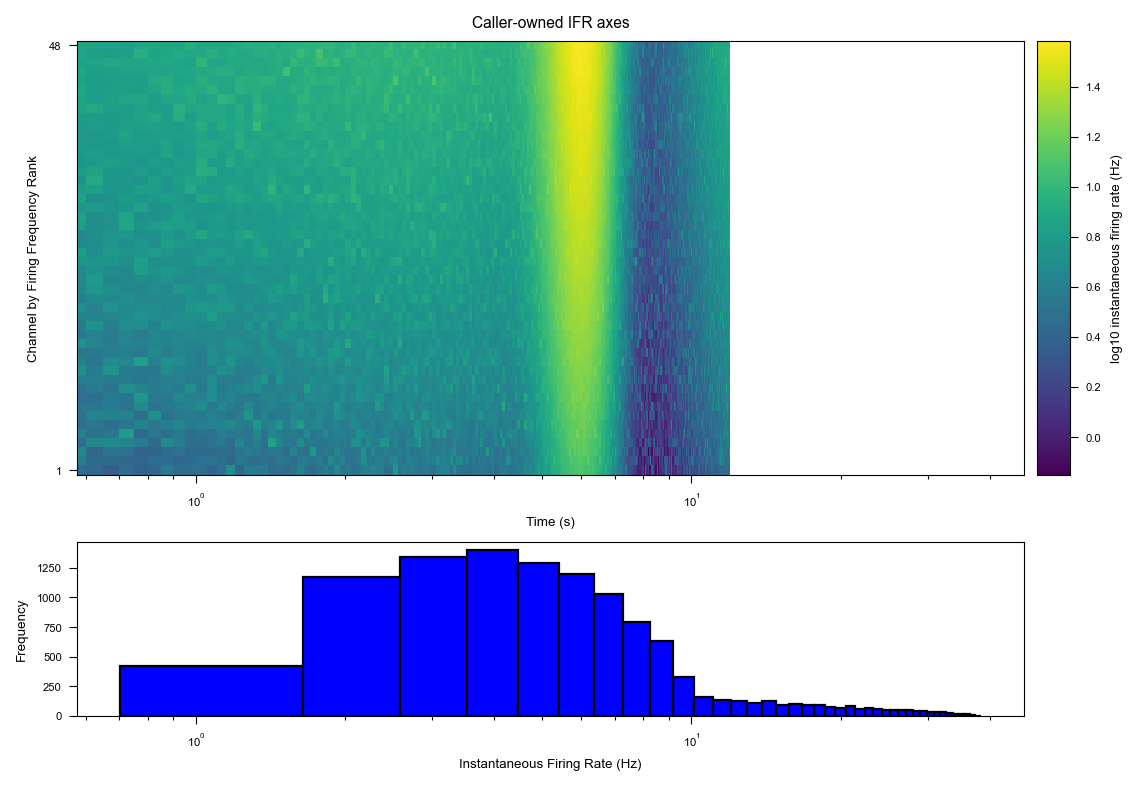

In [33]:
fig = plt.figure(figsize=(7.0, 4.8), constrained_layout=True)
axes = ifr_timeseries_axes_factory(fig, fig.add_gridspec(1, 1)[0, 0])

rendered = draw_ifr_timeseries_panel(
    ifr_panel,
    axes,
    ifr_config,
    recording_label="Compact draw call",
    compact=True,
)

axes[0].set_title("Caller-owned IFR axes")

## 5. Stage 3b: stitch repeated child plots under one panel label

Related repeated plots can share one panel label and one colorbar. Here two co-firing heatmaps function as subpanels within panel `a`.

Text(0.5, 1.0, 'day 2')

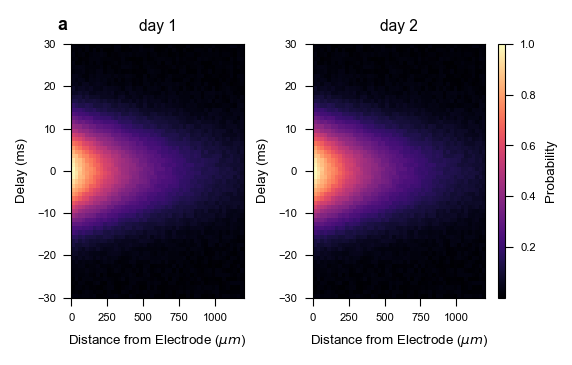

In [34]:
grouped = compose_figure(
    figure(width="one_column", height_mm=55.0),
    [
        group(
            "cofiring_days",
            label="a",
            loc=(0, 0, 1, 12),
            shared_colorbar=True,
            children=[
                panel(
                    "day_1",
                    draw=draw_cofiring_heatmap,
                    data=cofiring,
                ),
                panel(
                    "day_2",
                    draw=draw_cofiring_heatmap,
                    data=cofiring,
                ),
            ],
        )
    ],
)
grouped.axes["cofiring_days"]["day_1"].set_title("day 1")
grouped.axes["cofiring_days"]["day_2"].set_title("day 2")

## 6. Stage 4: compose a full paper figure

The outer grid defaults to 12 columns. Each `panel()` chooses which row and column span it occupies through `loc=(row, col, rowspan, colspan)`. Panels that need nested axes, such as heatmap plus trace plus colorbar, provide an `axes_factory`. The example below uses Nature's original-research two-column width preset.

[]


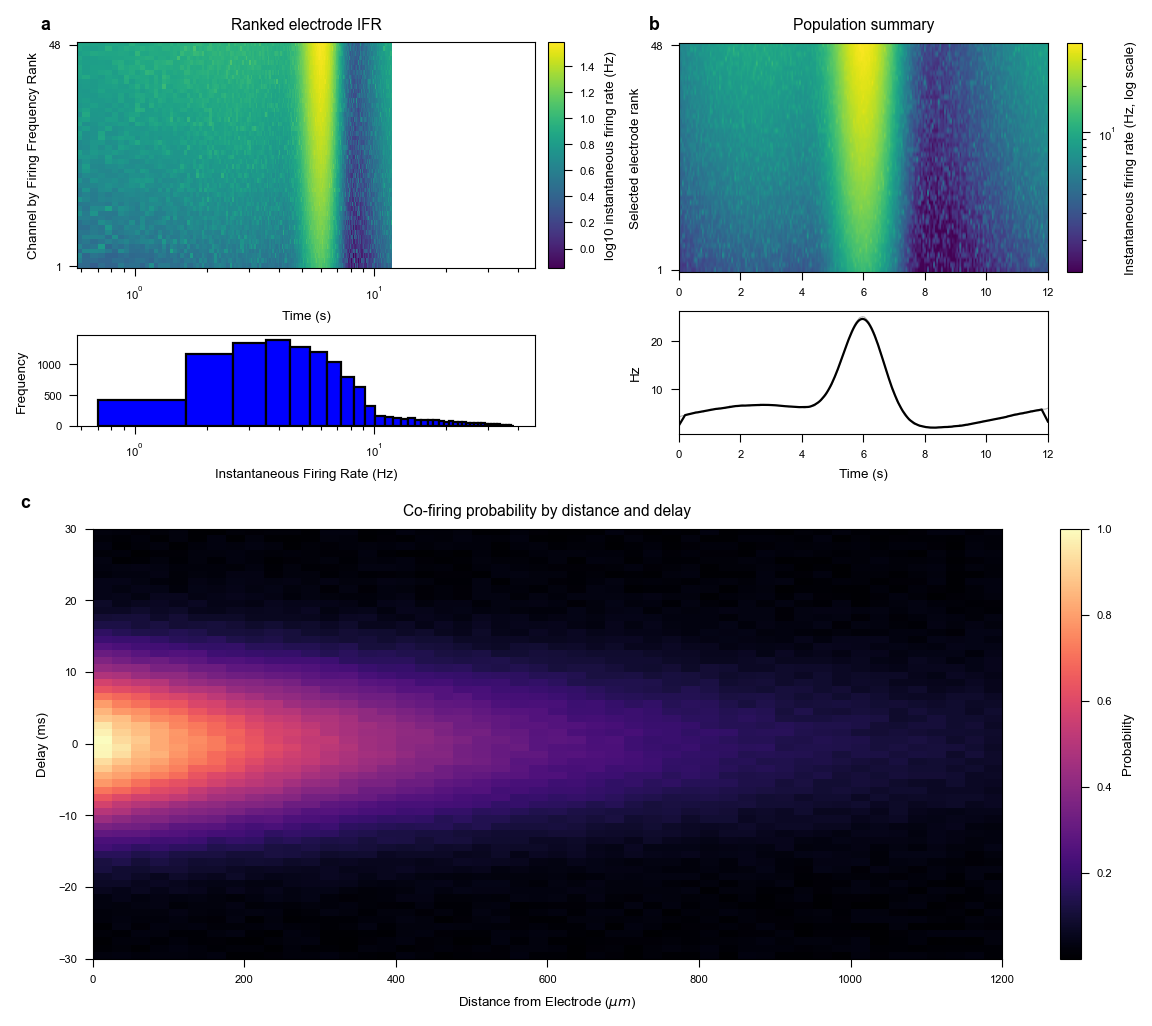

In [35]:
composed = compose_figure(
    figure(width="two_column", height_mm=160.0, rows=[1.0, 0.9]),
    [
        panel(
            "ifr",
            label="a",
            loc=(0, 0, 1, 7),
            draw=lambda data, axes, **opts: draw_ifr_timeseries_panel(data, axes, ifr_config, **opts),
            data=ifr_panel,
            axes_factory=ifr_timeseries_axes_factory,
        ),
        panel(
            "population",
            label="b",
            loc=(0, 7, 1, 5),
            draw=draw_population_ifr_summary,
            data=population,
            options={"show_legend": False},
            axes_factory=population_ifr_summary_axes_factory,
        ),
        panel(
            "cofiring",
            label="c",
            loc=(1, 0, 1, 12),
            draw=draw_cofiring_heatmap,
            data=cofiring,
        ),
    ],
)

composed.axes["ifr"][0].set_title("Ranked electrode IFR")
composed.axes["population"][0].set_title("Population summary")
composed.axes["cofiring"].set_title("Co-firing probability by distance and delay")
preflight_warnings = nature_figure_check(composed.fig)
print(preflight_warnings)

## 7. Add reusable annotation helpers

Panel labels are added automatically by `compose_figure`. Other helpers, such as scale bars, can be applied directly to the relevant axes.

In [36]:
ax = composed.axes["cofiring"]
add_scale_bar(ax, size=250.0, label="250 um", location="lower right", color="white")

(<matplotlib.lines.Line2D at 0x7fe6319c7940>,
 Text(1003.0, -27.599999999999998, '250 um'))

## 8. Export when ready

`export_figure` writes PDF, SVG, and PNG by default, using Nature-compatible embedded-font settings and 450 dpi for raster output. The cell below is disabled by default so the tutorial does not create files unless you opt in.

In [37]:
SAVE_FIGURE = False

if SAVE_FIGURE:
    export_figure(
        composed.fig,
        repo_root / "outputs" / "tutorial" / "composable_multipanel_demo",
        dpi=450,
    )

## Pattern to reuse

For a new panel type, aim for this split:

1. compute or load a result object outside plotting;
2. implement `draw_my_panel(result, axes, *, compact=False, show_legend=None, show_colorbar=None, ...)`;
3. keep `plot_my_panel(result, ...)` as a thin convenience wrapper for notebooks;
4. pass the draw function into `panel(...)` or grouped `group(...)` calls for composed figures.